# 🐾 Preprocesamiento — Austin Animal Center
**Target:** `outcome_type`  
**Pasos:**
1. Carga de intakes y outcomes
2. Merge de datasets
3. Eliminación de duplicados
4. Tratamiento de nulos
5. Feature engineering (edad, tiempo en refugio, estación)
6. One-Hot Encoding de `season` y otras categóricas
7. Exportar dataset limpio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## 1. Carga de datasets

In [2]:
# ── Ajusta las rutas a tus archivos CSV ──────────────────────────────────────
INTAKES_PATH  = '../data/raw/Austin_Animal_Center_Intakes.csv'
OUTCOMES_PATH = '../data/raw/Austin_Animal_Center_Outcomes.csv'

intakes  = pd.read_csv(INTAKES_PATH,  low_memory=False)
outcomes = pd.read_csv(OUTCOMES_PATH, low_memory=False)

print(f'Intakes  → {intakes.shape[0]:,} filas × {intakes.shape[1]} columnas')
print(f'Outcomes → {outcomes.shape[0]:,} filas × {outcomes.shape[1]} columnas')

Intakes  → 124,120 filas × 12 columnas
Outcomes → 124,491 filas × 12 columnas


In [3]:
print('=== COLUMNAS INTAKES ===')
print(intakes.columns.tolist())
print('\n=== COLUMNAS OUTCOMES ===')
print(outcomes.columns.tolist())

=== COLUMNAS INTAKES ===
['Animal ID', 'Name', 'DateTime', 'MonthYear', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake', 'Age upon Intake', 'Breed', 'Color']

=== COLUMNAS OUTCOMES ===
['Animal ID', 'Name', 'DateTime', 'MonthYear', 'Date of Birth', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']


In [4]:
intakes.head(3)

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
0,A786884,*Brock,01/03/2019 04:19:00 PM,01/03/2019 04:19:00 PM,2501 Magin Meadow Dr in Austin (TX),Stray,Normal,Dog,Neutered Male,2 years,Beagle Mix,Tricolor
1,A706918,Belle,07/05/2015 12:59:00 PM,07/05/2015 12:59:00 PM,9409 Bluegrass Dr in Austin (TX),Stray,Normal,Dog,Spayed Female,8 years,English Springer Spaniel,White/Liver
2,A724273,Runster,04/14/2016 06:43:00 PM,04/14/2016 06:43:00 PM,2818 Palomino Trail in Austin (TX),Stray,Normal,Dog,Intact Male,11 months,Basenji Mix,Sable/White


In [5]:
outcomes.head(3)

,Animal ID,Name,DateTime,MonthYear,Date of Birth,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A794011,Chunk,05/08/2019 06:20:00 PM,05/08/2019 06:20:00 PM,05/02/2017,Rto-Adopt,NaN,Cat,Neutered Male,2 years,Domestic Shorthair Mix,Brown Tabby/White
1,A776359,Gizmo,07/18/2018 04:02:00 PM,07/18/2018 04:02:00 PM,07/12/2017,Adoption,NaN,Dog,Neutered Male,1 year,Chihuahua Shorthair Mix,White/Brown
2,A821648,NaN,08/16/2020 11:38:00 AM,08/16/2020 11:38:00 AM,08/16/2019,Euthanasia,NaN,Other,Unknown,1 year,Raccoon,Gray


Cuales son *outcome_type* que tenemos 

In [3]:
df = pd.read_csv('../data/processed/austin_animal_preprocessed.csv')
print(df.columns.tolist())
print(df['outcome_type'].value_counts())

['animal_id', 'name_outcome', 'datetime_outcome', 'monthyear_outcome', 'date_of_birth', 'outcome_type', 'animal_type_outcome', 'sex_upon_outcome', 'age_upon_outcome', 'breed_outcome', 'color_outcome', 'name_intake', 'datetime_intake', 'monthyear_intake', 'found_location', 'intake_type', 'intake_condition', 'animal_type_intake', 'sex_upon_intake', 'age_upon_intake', 'breed_intake', 'color_intake', 'outcome_year', 'outcome_month', 'outcome_dow', 'outcome_hour', 'is_weekend', 'days_in_shelter', 'season', 'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter', 'age_days', 'is_mix', 'sex', 'repro_status', 'outcome_type_encoded']
outcome_type
Adoption           72387
Transfer           40040
Return To Owner    36005
Euthanasia          8705
Rto-Adopt           1325
Died                1182
Disposal             572
Missing               93
Unknown               28
Relocate              21
Name: count, dtype: int64


---
## 2. Normalización de nombres de columnas

In [6]:
def clean_col_names(df):
    """Lowercase, reemplaza espacios y caracteres raros por _"""
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[\s\(\)/]+', '_', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )
    return df

intakes  = clean_col_names(intakes)
outcomes = clean_col_names(outcomes)

print('Columnas intakes  :', intakes.columns.tolist())
print('Columnas outcomes :', outcomes.columns.tolist())

Columnas intakes  : ['animal_id', 'name', 'datetime', 'monthyear', 'found_location', 'intake_type', 'intake_condition', 'animal_type', 'sex_upon_intake', 'age_upon_intake', 'breed', 'color']
Columnas outcomes : ['animal_id', 'name', 'datetime', 'monthyear', 'date_of_birth', 'outcome_type', 'outcome_subtype', 'animal_type', 'sex_upon_outcome', 'age_upon_outcome', 'breed', 'color']


---
## 3. Merge: Intakes + Outcomes

In [7]:
# ── Renombrar columnas duplicadas antes del merge ────────────────────────────
# Columnas que existen en ambos y NO son la clave de join → añadir sufijo
shared_non_key = [c for c in intakes.columns
                  if c in outcomes.columns and c != 'animal_id']
print('Columnas compartidas (se añadirá sufijo _intake/_outcome):', shared_non_key)

intakes  = intakes.rename(columns={c: f'{c}_intake'  for c in shared_non_key})
outcomes = outcomes.rename(columns={c: f'{c}_outcome' for c in shared_non_key})

Columnas compartidas (se añadirá sufijo _intake/_outcome): ['name', 'datetime', 'monthyear', 'animal_type', 'breed', 'color']


In [8]:
# Merge por animal_id (un animal puede tener múltiples entradas → muchos a muchos)
# Usamos merge inner para quedarnos solo con animales que tienen ambos registros
df = pd.merge(outcomes, intakes, on='animal_id', how='inner')

print(f'Dataset combinado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

Dataset combinado: 160,428 filas × 23 columnas


,animal_id,name_outcome,datetime_outcome,monthyear_outcome,date_of_birth,outcome_type,outcome_subtype,animal_type_outcome,sex_upon_outcome,age_upon_outcome,...,datetime_intake,monthyear_intake,found_location,intake_type,intake_condition,animal_type_intake,sex_upon_intake,age_upon_intake,breed_intake,color_intake
0,A794011,Chunk,05/08/2019 06:20:00 PM,05/08/2019 06:20:00 PM,05/02/2017,Rto-Adopt,NaN,Cat,Neutered Male,2 years,...,05/02/2019 04:51:00 PM,05/02/2019 04:51:00 PM,Austin (TX),Owner Surrender,Normal,Cat,Neutered Male,2 years,Domestic Shorthair Mix,Brown Tabby/White
1,A776359,Gizmo,07/18/2018 04:02:00 PM,07/18/2018 04:02:00 PM,07/12/2017,Adoption,NaN,Dog,Neutered Male,1 year,...,07/12/2018 12:46:00 PM,07/12/2018 12:46:00 PM,7201 Levander Loop in Austin (TX),Stray,Normal,Dog,Intact Male,1 year,Chihuahua Shorthair Mix,White/Brown
2,A821648,NaN,08/16/2020 11:38:00 AM,08/16/2020 11:38:00 AM,08/16/2019,Euthanasia,NaN,Other,Unknown,1 year,...,08/16/2020 10:10:00 AM,08/16/2020 10:10:00 AM,Armadillo Rd And Clubway Ln in Austin (TX),Wildlife,Sick,Other,Unknown,1 year,Raccoon,Gray


---
## 4. Eliminación de duplicados

In [9]:
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)

print(f'Filas antes : {n_before:,}')
print(f'Filas después: {n_after:,}')
print(f'Duplicados eliminados: {n_before - n_after:,}')

Filas antes : 160,428
Filas después: 160,358
Duplicados eliminados: 70


---
## 5. Diagnóstico de nulos

In [10]:
null_summary = pd.DataFrame({
    'nulos':       df.isnull().sum(),
    'porcentaje':  (df.isnull().mean() * 100).round(2)
}).sort_values('porcentaje', ascending=False)

null_summary = null_summary[null_summary['nulos'] > 0]
print(f'Columnas con nulos: {len(null_summary)}')
display(null_summary.style.bar(subset=['porcentaje'], color='#d65f5f'))

Columnas con nulos: 7


,nulos,porcentaje
outcome_subtype,97591,60.860000
name_outcome,39775,24.800000
name_intake,39775,24.800000
outcome_type,28,0.020000
age_upon_outcome,5,0.000000
sex_upon_outcome,1,0.000000
sex_upon_intake,1,0.000000


---
## 6. Tratamiento de nulos

In [11]:
# ── 6.1  Columnas con >50% nulos → eliminar ──────────────────────────────────
HIGH_NULL_THRESHOLD = 50
cols_to_drop = null_summary[null_summary['porcentaje'] > HIGH_NULL_THRESHOLD].index.tolist()

print(f'Columnas con >{HIGH_NULL_THRESHOLD}% nulos (se eliminan): {cols_to_drop}')
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

Columnas con >50% nulos (se eliminan): ['outcome_subtype']


In [12]:
# ── 6.2  Columna 'name' → rellenar con 'Unknown' ─────────────────────────────
if 'name' in df.columns:
    df['name'] = df['name'].fillna('Unknown')
    print('name: nulos → "Unknown"')

# ── 6.3  outcome_subtype → rellenar con 'None' ───────────────────────────────
if 'outcome_subtype' in df.columns:
    df['outcome_subtype'] = df['outcome_subtype'].fillna('None')
    print('outcome_subtype: nulos → "None"')

# ── 6.4  sex_upon_outcome → moda ─────────────────────────────────────────────
for col in ['sex_upon_outcome', 'sex_upon_intake']:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'{col}: nulos → "{mode_val}" (moda)')

# ── 6.5  Columnas numéricas restantes → mediana ───────────────────────────────
num_cols_with_null = df.select_dtypes(include=[np.number]).columns[
    df.select_dtypes(include=[np.number]).isnull().any()
]
for col in num_cols_with_null:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'{col}: nulos → mediana ({med})')

# ── 6.6  Categóricas restantes → 'Unknown' ───────────────────────────────────
remaining_nulls = df.columns[df.isnull().any()].tolist()
for col in remaining_nulls:
    df[col] = df[col].fillna('Unknown')
    print(f'{col}: nulos → "Unknown"')

print(f'\n✅ Nulos restantes: {df.isnull().sum().sum()}')

sex_upon_outcome: nulos → "Neutered Male" (moda)
sex_upon_intake: nulos → "Intact Male" (moda)
name_outcome: nulos → "Unknown"
outcome_type: nulos → "Unknown"
age_upon_outcome: nulos → "Unknown"
name_intake: nulos → "Unknown"

✅ Nulos restantes: 0


---
## 7. Parseo de fechas y Feature Engineering

In [13]:
# ── 7.1  Detectar y parsear columnas de fecha ─────────────────────────────────
# Columnas típicas del dataset
DATE_COLS = {
    'datetime_outcome': ['datetime_outcome', 'outcome_datetime', 'datetime'],
    'datetime_intake':  ['datetime_intake',  'intake_datetime']
}

# Mapeo automático: busca la primera columna que exista
found_dates = {}
for alias, candidates in DATE_COLS.items():
    for c in candidates:
        if c in df.columns:
            df[alias] = pd.to_datetime(df[c], errors='coerce')
            found_dates[alias] = c
            print(f'✅ {alias} → parseado desde "{c}"')
            break

if 'datetime_outcome' not in found_dates:
    print('⚠️  No se encontró columna de fecha de outcome. Revisa el nombre en tu CSV.')

✅ datetime_outcome → parseado desde "datetime_outcome"
✅ datetime_intake → parseado desde "datetime_intake"


In [14]:
# ── 7.2  Features temporales del OUTCOME ─────────────────────────────────────
if 'datetime_outcome' in df.columns:
    df['outcome_year']    = df['datetime_outcome'].dt.year
    df['outcome_month']   = df['datetime_outcome'].dt.month
    df['outcome_dow']     = df['datetime_outcome'].dt.dayofweek   # 0=lunes
    df['outcome_hour']    = df['datetime_outcome'].dt.hour
    df['is_weekend']      = (df['outcome_dow'] >= 5).astype(int)
    print('✅ Features temporales creadas: outcome_year, outcome_month, outcome_dow, outcome_hour, is_weekend')

✅ Features temporales creadas: outcome_year, outcome_month, outcome_dow, outcome_hour, is_weekend


In [15]:
# ── 7.3  Tiempo en el refugio (días) ─────────────────────────────────────────
if 'datetime_outcome' in df.columns and 'datetime_intake' in df.columns:
    df['days_in_shelter'] = (
        df['datetime_outcome'] - df['datetime_intake']
    ).dt.days

    # Eliminar casos negativos (error de datos)
    invalid = (df['days_in_shelter'] < 0).sum()
    df.loc[df['days_in_shelter'] < 0, 'days_in_shelter'] = np.nan
    df['days_in_shelter'] = df['days_in_shelter'].fillna(df['days_in_shelter'].median())

    print(f'✅ days_in_shelter creada  |  Valores negativos corregidos: {invalid}')
    print(df['days_in_shelter'].describe().round(1))

✅ days_in_shelter creada  |  Valores negativos corregidos: 19090
count    160358.0
mean         52.5
std         173.5
min           0.0
25%           3.0
50%           6.0
75%          24.0
max        2553.0
Name: days_in_shelter, dtype: float64


---
## 8. Creación de la variable `season` (Estación del año)

Se crea a partir del **mes del outcome** y luego se aplica **One-Hot Encoding**.

| Meses       | Estación     |
|-------------|-------------|
| 12, 1, 2    | Winter       |
| 3, 4, 5     | Spring       |
| 6, 7, 8     | Summer       |
| 9, 10, 11   | Fall         |

In [16]:
def month_to_season(month):
    """Devuelve la estación meteorológica (hemisferio norte) dado un número de mes."""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Fall'

df['season'] = df['outcome_month'].apply(month_to_season)

print('✅ Variable season creada')
print(df['season'].value_counts())

✅ Variable season creada
season
Summer    43412
Fall      41508
Winter    38214
Spring    37224
Name: count, dtype: int64


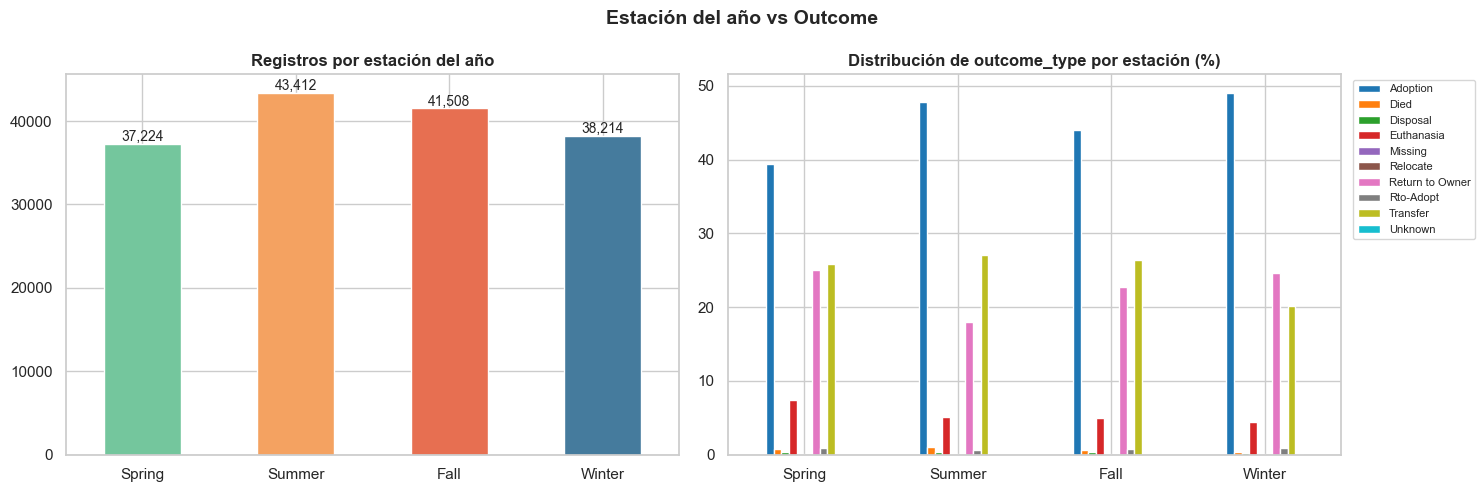

In [17]:
# Visualización: distribución de outcomes por estación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

season_order = ['Spring', 'Summer', 'Fall', 'Winter']

# Conteo por estación
season_counts = df['season'].value_counts().reindex(season_order)
colors = ['#74c69d', '#f4a261', '#e76f51', '#457b9d']
season_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Registros por estación del año', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Outcome por estación (normalizado)
ct = pd.crosstab(df['season'], df['outcome_type'], normalize='index') * 100
ct = ct.reindex([s for s in season_order if s in ct.index])
ct.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Distribución de outcome_type por estación (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xlabel('')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Estación del año vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. One-Hot Encoding de `season`

In [18]:
# One-Hot Encoding de season con drop_first=False para ver las 4 columnas
# (drop_first=True eliminaría una para evitar multicolinealidad en regresión)
season_dummies = pd.get_dummies(df['season'], prefix='season', dtype=int)

print('Columnas OHE generadas:', season_dummies.columns.tolist())
display(season_dummies.head(5))

df = pd.concat([df, season_dummies], axis=1)
print(f'\n✅ OHE de season añadido. Shape actual: {df.shape}')

Columnas OHE generadas: ['season_Fall', 'season_Spring', 'season_Summer', 'season_Winter']


,season_Fall,season_Spring,season_Summer,season_Winter
0,0,1,0,0
1,0,0,1,0
2,0,0,1,0
3,0,0,0,1
4,0,0,0,1



✅ OHE de season añadido. Shape actual: (160358, 33)


In [19]:
# Verificación: conteo de 1s por columna OHE (debe coincidir con value_counts de season)
ohe_cols = [c for c in df.columns if c.startswith('season_')]
print('Suma por columna OHE:')
print(df[ohe_cols].sum().to_string())

Suma por columna OHE:
season_Fall      41508
season_Spring    37224
season_Summer    43412
season_Winter    38214


---
## 10. Conversión de edad a días

In [20]:
def age_to_days(age_str):
    """
    Convierte strings como '2 years', '3 months', '10 days', '1 week'
    a número de días (float). Devuelve NaN si no puede parsear.
    """
    if pd.isnull(age_str):
        return np.nan
    age_str = str(age_str).strip().lower()
    multipliers = {'year': 365, 'years': 365,
                   'month': 30,  'months': 30,
                   'week': 7,    'weeks': 7,
                   'day': 1,     'days': 1}
    parts = age_str.split()
    if len(parts) == 2:
        try:
            number, unit = parts
            return float(number) * multipliers.get(unit, np.nan)
        except:
            return np.nan
    return np.nan

# Detectar columna de edad
age_col = None
for c in ['age_upon_outcome', 'age_upon_outcome_intake']:
    if c in df.columns:
        age_col = c
        break

if age_col:
    df['age_days'] = df[age_col].apply(age_to_days)
    df['age_days'] = df['age_days'].fillna(df['age_days'].median())
    print(f'✅ age_days creada desde "{age_col}"')
    print(df['age_days'].describe().round(1))
else:
    print('⚠️  Columna de edad no encontrada. Ajusta age_col manualmente.')

✅ age_days creada desde "age_upon_outcome"
count    160358.0
mean        822.8
std        1043.3
min       -1095.0
25%         120.0
50%         365.0
75%        1095.0
max        9125.0
Name: age_days, dtype: float64


---
## 11. Feature: is_mix (raza mixta)

In [21]:
breed_col = None
for c in ['breed_outcome', 'breed_intake', 'breed']:
    if c in df.columns:
        breed_col = c
        break

if breed_col:
    df['is_mix'] = df[breed_col].str.lower().str.contains('mix', na=False).astype(int)
    print(f'✅ is_mix creada desde "{breed_col}"')
    print(df['is_mix'].value_counts())

✅ is_mix creada desde "breed_outcome"
is_mix
1    118115
0     42243
Name: count, dtype: int64


---
## 12. Separar sexo y estado reproductivo

In [22]:
sex_col = None
for c in ['sex_upon_outcome', 'sex_upon_outcome_outcome']:
    if c in df.columns:
        sex_col = c
        break

if sex_col:
    def parse_sex(val):
        val = str(val).lower().strip()
        if 'male' in val:
            sex = 'Male'
        elif 'female' in val:
            sex = 'Female'
        else:
            sex = 'Unknown'
        if 'neutered' in val or 'spayed' in val:
            repro = 'Fixed'
        elif 'intact' in val:
            repro = 'Intact'
        else:
            repro = 'Unknown'
        return sex, repro

    df[['sex', 'repro_status']] = df[sex_col].apply(
        lambda x: pd.Series(parse_sex(x))
    )
    print(f'✅ sex y repro_status creadas desde "{sex_col}"')
    print('\nsex:')
    print(df['sex'].value_counts())
    print('\nrepro_status:')
    print(df['repro_status'].value_counts())

✅ sex y repro_status creadas desde "sex_upon_outcome"

sex:
sex
Male       150117
Unknown     10241
Name: count, dtype: int64

repro_status:
repro_status
Fixed      115218
Intact      34899
Unknown     10241
Name: count, dtype: int64


---
## 13. Limpieza del target y encoding

In [23]:
TARGET = 'outcome_type'

# Revisar valores únicos del target
print('Valores únicos en outcome_type:')
print(df[TARGET].value_counts())

Valores únicos en outcome_type:
outcome_type
Adoption           72387
Transfer           40040
Return to Owner    36005
Euthanasia          8705
Rto-Adopt           1325
Died                1182
Disposal             572
Missing               93
Unknown               28
Relocate              21
Name: count, dtype: int64


In [24]:
# Eliminar filas donde el target sea nulo
before = len(df)
df = df.dropna(subset=[TARGET])
print(f'Filas eliminadas por target nulo: {before - len(df)}')

# Estandarizar a Title Case
df[TARGET] = df[TARGET].str.strip().str.title()

# Label Encoding del target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['outcome_type_encoded'] = le.fit_transform(df[TARGET])

# Mapa de clases
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('\nMapeo de clases:')
for k, v in class_mapping.items():
    print(f'  {v} → {k}')

Filas eliminadas por target nulo: 0

Mapeo de clases:
  0 → Adoption
  1 → Died
  2 → Disposal
  3 → Euthanasia
  4 → Missing
  5 → Relocate
  6 → Return To Owner
  7 → Rto-Adopt
  8 → Transfer
  9 → Unknown


---
## 14. Resumen del dataset final

In [25]:
print('=' * 60)
print('         📊 RESUMEN DEL DATASET PREPROCESADO')
print('=' * 60)
print(f'Shape final : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Nulos restantes: {df.isnull().sum().sum()}')
print(f'Duplicados restantes: {df.duplicated().sum()}')

print('\n── Nuevas features creadas ──────────────────────────────')
new_features = [
    'outcome_year', 'outcome_month', 'outcome_dow', 'outcome_hour',
    'is_weekend', 'days_in_shelter', 'season',
    'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter',
    'age_days', 'is_mix', 'sex', 'repro_status', 'outcome_type_encoded'
]
for f in new_features:
    exists = '✅' if f in df.columns else '❌'
    print(f'  {exists} {f}')

print('\n── Distribución del target ──────────────────────────────')
print(df[TARGET].value_counts())

         📊 RESUMEN DEL DATASET PREPROCESADO
Shape final : 160,358 filas × 38 columnas
Nulos restantes: 0
Duplicados restantes: 0

── Nuevas features creadas ──────────────────────────────
  ✅ outcome_year
  ✅ outcome_month
  ✅ outcome_dow
  ✅ outcome_hour
  ✅ is_weekend
  ✅ days_in_shelter
  ✅ season
  ✅ season_Fall
  ✅ season_Spring
  ✅ season_Summer
  ✅ season_Winter
  ✅ age_days
  ✅ is_mix
  ✅ sex
  ✅ repro_status
  ✅ outcome_type_encoded

── Distribución del target ──────────────────────────────
outcome_type
Adoption           72387
Transfer           40040
Return To Owner    36005
Euthanasia          8705
Rto-Adopt           1325
Died                1182
Disposal             572
Missing               93
Unknown               28
Relocate              21
Name: count, dtype: int64


In [26]:
# Vista de columnas finales del dataset
df.dtypes.to_frame('dtype').T

,animal_id,name_outcome,datetime_outcome,monthyear_outcome,date_of_birth,outcome_type,animal_type_outcome,sex_upon_outcome,age_upon_outcome,breed_outcome,...,season,season_Fall,season_Spring,season_Summer,season_Winter,age_days,is_mix,sex,repro_status,outcome_type_encoded
dtype,str,str,datetime64[us],str,str,str,str,str,str,str,...,str,int64,int64,int64,int64,float64,int64,str,str,int64


---
## 15. Exportar dataset limpio

In [ ]:
OUTPUT_PATH = '../data/processed/austin_animal_preprocessed.csv'
df.to_csv(OUTPUT_PATH, index=False)
print(f'✅ Dataset guardado en: {OUTPUT_PATH}')
print(f'   Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✅ Dataset guardado en: austin_animal_preprocessed.csv
   Shape: 160,358 filas × 38 columnas


---
## 🚀 Próximos pasos

El dataset ya está listo para modelado. Los pasos siguientes serían:

1. **Selección de features** — usar Cramér's V y feature importance del EDA
2. **Split train/test** — `train_test_split` con `stratify=y`
3. **Escalar features numéricas** — `StandardScaler` o `MinMaxScaler`
4. **Manejar desbalance** — `class_weight='balanced'` o SMOTE
5. **Entrenar modelos** — Logistic Regression → Random Forest → XGBoost
6. **Evaluar** — F1-macro, ROC-AUC multiclase, Confusion Matrix